# Statistical Modeling and Inferencing — Assignment 1
## Medical Insurance Charges Dataset

**Name:** Mohammed Niyaz Ali
**Roll No:** 2025EM1200278
**Dataset:** Medical Insurance Charges (Dataset 1)

---

## Summary

In this assignment I will analyze the Medical Insurance Charges dataset containing 1,338
observations with 6 features (age, sex, bmi, children, smoker, region) to predict
insurance charges using regression modeling.

My approach follows three parts: first I explore and prepare the data including encoding
categorical variables and checking for outliers. Then I develop and compare 4 regression
models — Simple Linear, Multiple Linear, Multiple Linear with Log target, and Polynomial
Regression. Finally I will interpret the key findings and provide actionable insights.

In [2]:
# Importing all necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# Load dataset
df = pd.read_csv('insurance.csv')

print("Dataset loaded successfully!")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

Dataset loaded successfully!
Rows: 1338, Columns: 7


## Part 1 — Data Exploration and Preparation
### 1.1 First Look at the Data

Before building any models I want to understand what the dataset looks like,
checking data quality and explore relationships between variables.

In [3]:
# First 10 entries in the dataset
df.head(10)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


In [4]:
# Data types and null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [5]:
# Descriptive statistics
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


### 1.2 Feature Overview

The dataset has 7 columns:

| Feature | Type | Description |
|---|---|---|
| age | Numeric | Age of the insurance holder (18–64) |
| sex | Categorical | male or female |
| bmi | Numeric | Body Mass Index |
| children | Numeric | Number of dependents covered |
| smoker | Categorical | yes or no |
| region | Categorical | southwest, southeast, northwest, northeast |
| charges | Numeric | Medical insurance cost |

The dataset has no missing values so no imputation is needed.
The three categorical variables (sex, smoker, region) need encoding before regression.

In [6]:
# Check missing values
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing: {df.isnull().sum().sum()}")

# Unique values for categorical columns
print("\nUnique values:")
for col in ['sex', 'smoker', 'region']:
    print(f"  {col}: {df[col].unique().tolist()}")

# Value counts
print("\nSmoker distribution:")
print(df['smoker'].value_counts())
print(f"\nSmoker rate: {(df['smoker']=='yes').mean()*100:.1f}%")

Missing values per column:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Total missing: 0

Unique values:
  sex: ['female', 'male']
  smoker: ['yes', 'no']
  region: ['southwest', 'southeast', 'northwest', 'northeast']

Smoker distribution:
smoker
no     1064
yes     274
Name: count, dtype: int64

Smoker rate: 20.5%


### 1.3 Distribution Plots

I will check the shape of each variable's distribution.
Charges is the target variable.

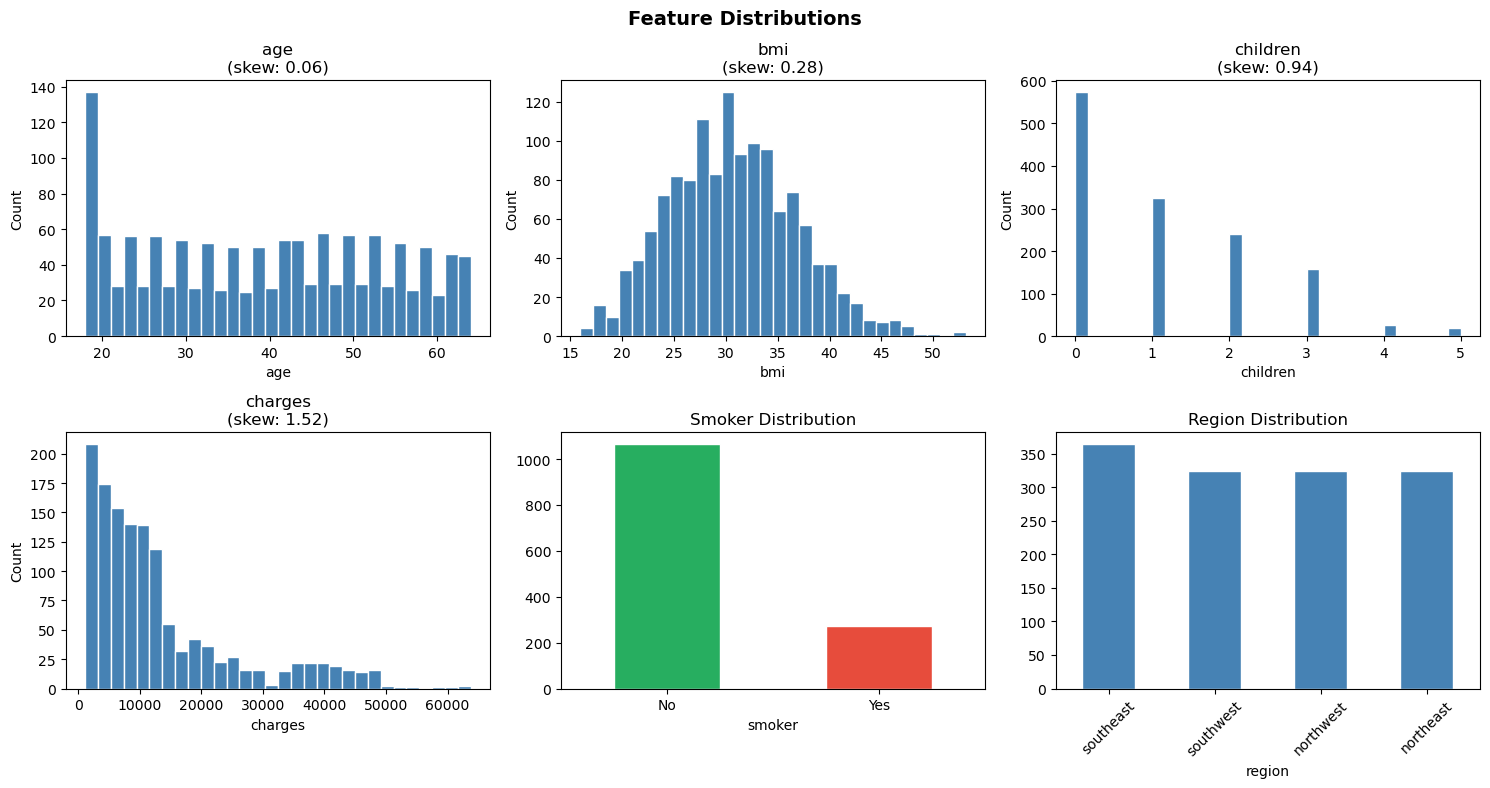

Skewness values:
  age: 0.056
  bmi: 0.284
  children: 0.938
  charges: 1.516 ← right skewed


In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

# Numeric distributions
for i, col in enumerate(['age', 'bmi', 'children', 'charges']):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='white')
    axes[i].set_title(f'{col}\n(skew: {df[col].skew():.2f})')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

# Smoker distribution
df['smoker'].value_counts().plot(kind='bar', ax=axes[4],
    color=['#27ae60','#e74c3c'], edgecolor='white')
axes[4].set_title('Smoker Distribution')
axes[4].set_xticklabels(['No', 'Yes'], rotation=0)

# Region distribution
df['region'].value_counts().plot(kind='bar', ax=axes[5],
    color='steelblue', edgecolor='white')
axes[5].set_title('Region Distribution')
axes[5].tick_params(axis='x', rotation=45)

plt.suptitle('Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Skewness values:")
for col in ['age', 'bmi', 'children', 'charges']:
    flag = " ← right skewed" if df[col].skew() > 1 else ""
    print(f"  {col}: {df[col].skew():.3f}{flag}")

### 1.4 Relationship Plots — Charges vs Each Feature

I want to check how each feature relates to insurance charges
before building models.

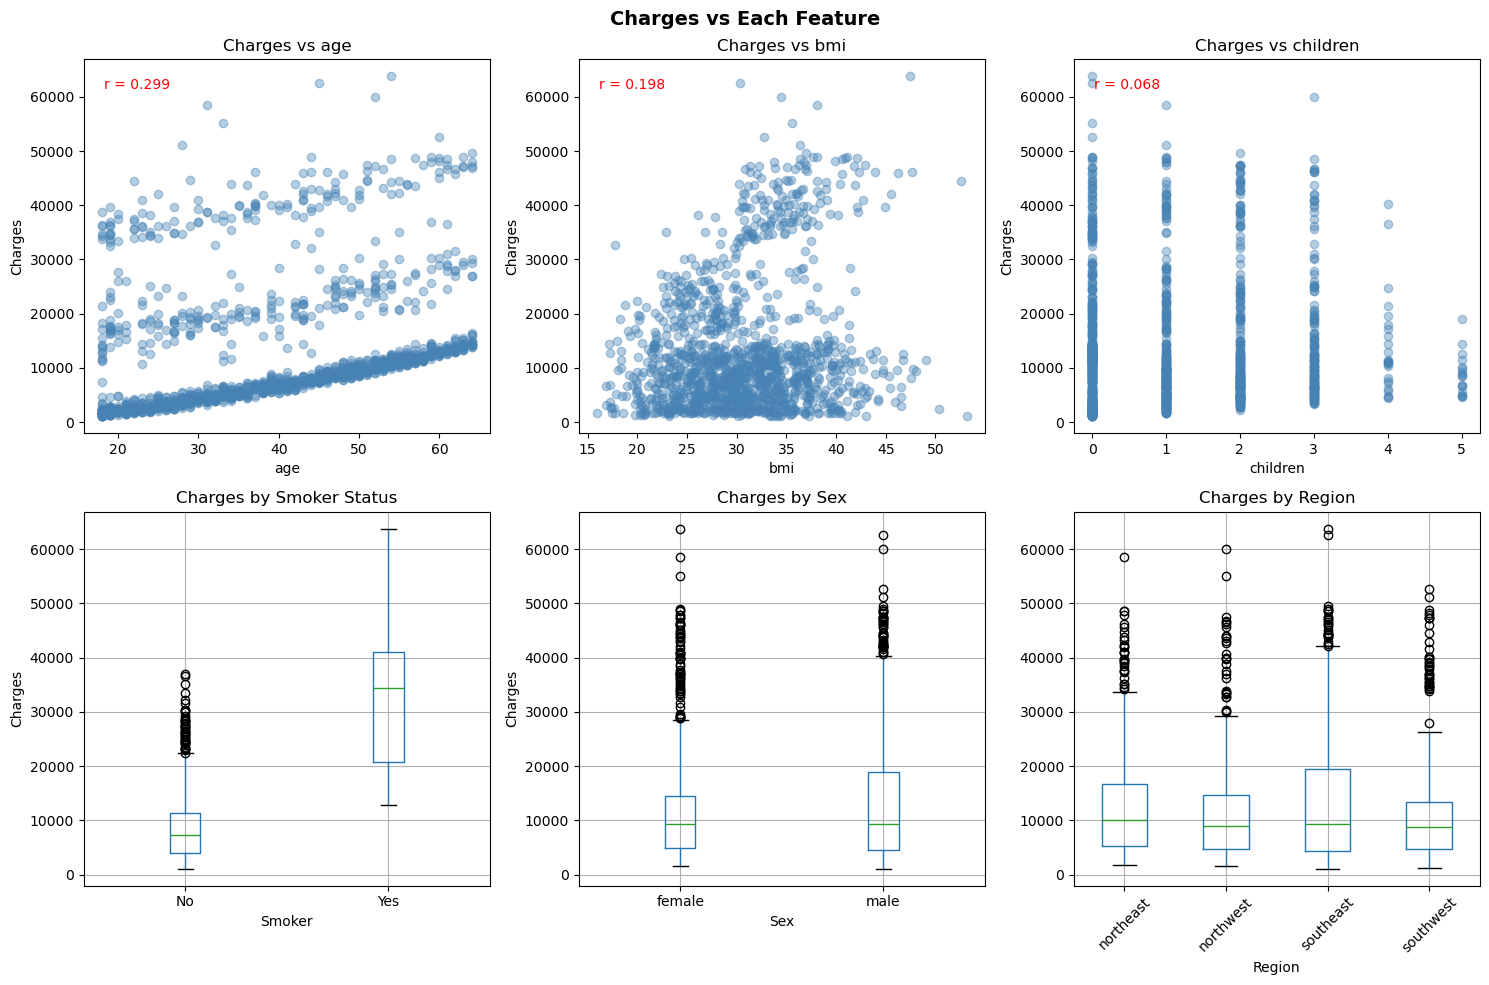

Mean charges by smoker status:
smoker
no      8434.27
yes    32050.23
Name: charges, dtype: float64

Smokers pay $23615.96 MORE on average


In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

# Scatter plots for numeric features
for i, col in enumerate(['age', 'bmi', 'children']):
    axes[i].scatter(df[col], df['charges'], alpha=0.4, color='steelblue')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Charges')
    axes[i].set_title(f'Charges vs {col}')
    corr = df[col].corr(df['charges'])
    axes[i].text(0.05, 0.95, f'r = {corr:.3f}',
                 transform=axes[i].transAxes, fontsize=10,
                 verticalalignment='top', color='red')

# Box plots for categorical features
df.boxplot(column='charges', by='smoker', ax=axes[3])
axes[3].set_title('Charges by Smoker Status')
axes[3].set_xlabel('Smoker')
axes[3].set_ylabel('Charges')
plt.sca(axes[3])
plt.xticks([1, 2], ['No', 'Yes'])

df.boxplot(column='charges', by='sex', ax=axes[4])
axes[4].set_title('Charges by Sex')
axes[4].set_xlabel('Sex')
axes[4].set_ylabel('Charges')

df.boxplot(column='charges', by='region', ax=axes[5])
axes[5].set_title('Charges by Region')
axes[5].set_xlabel('Region')
axes[5].tick_params(axis='x', rotation=45)

plt.suptitle('Charges vs Each Feature', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Mean charges by smoker status:")
print(df.groupby('smoker')['charges'].mean().round(2))
print(f"\nSmokers pay ${df[df['smoker']=='yes']['charges'].mean() - df[df['smoker']=='no']['charges'].mean():.2f} MORE on average")

### 1.5 Correlation Analysis

I will check correlations between all numeric features and the target variable.

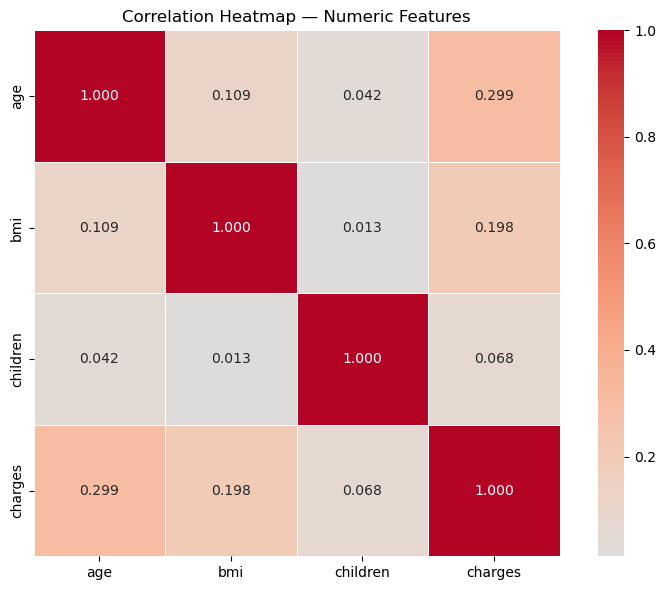

Correlation with charges (sorted):
charges     1.000
age         0.299
bmi         0.198
children    0.068
dtype: float64

Observation: age has the strongest correlation with charges among numeric features
However smoker (categorical) is expected to be the strongest overall predictor


In [9]:
# Correlation heatmap
plt.figure(figsize=(8, 6))
num_df = df[['age', 'bmi', 'children', 'charges']]
corr_matrix = num_df.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Correlation Heatmap — Numeric Features')
plt.tight_layout()
plt.show()

print("Correlation with charges (sorted):")
print(num_df.corrwith(df['charges']).sort_values(ascending=False).round(3))
print("\nObservation: age has the strongest correlation with charges among numeric features")
print("However smoker (categorical) is expected to be the strongest overall predictor")

### 1.6 Outlier Detection

I will check for outliers in numeric features using boxplots and IQR method.

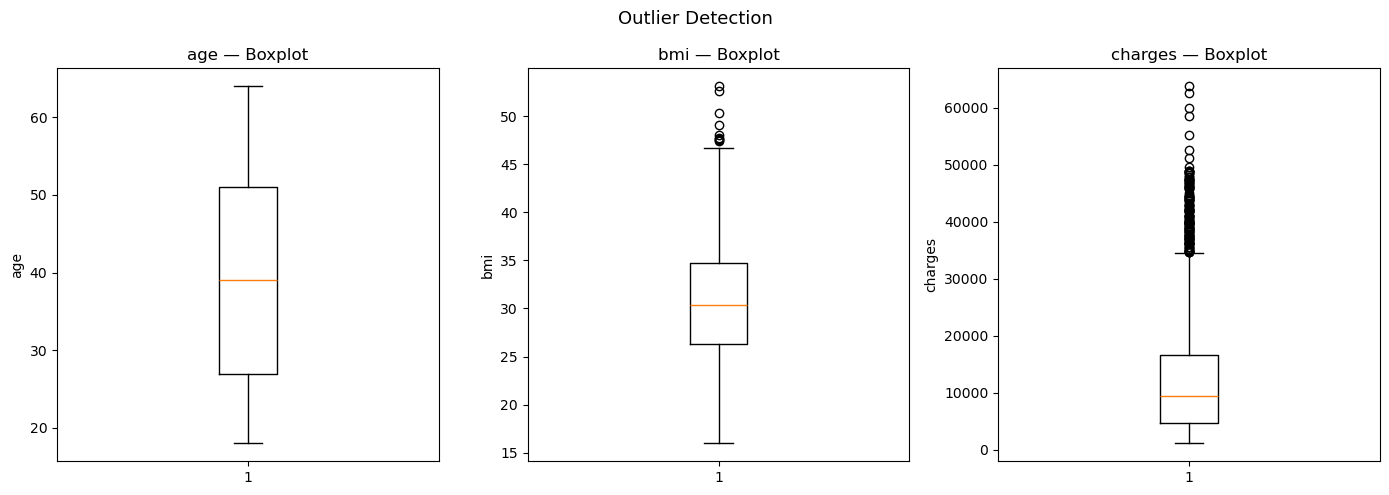

bmi: 9 outliers detected (IQR method)
charges: 139 outliers detected (IQR method)

Decision: Keep all outliers
Reason: They represent genuine high-cost patients — not data errors
Removing them would bias the model against predicting high insurance charges


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for i, col in enumerate(['age', 'bmi', 'charges']):
    axes[i].boxplot(df[col])
    axes[i].set_title(f'{col} — Boxplot')
    axes[i].set_ylabel(col)

plt.suptitle('Outlier Detection', fontsize=13)
plt.tight_layout()
plt.show()

# IQR method
for col in ['bmi', 'charges']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    print(f"{col}: {len(outliers)} outliers detected (IQR method)")

print("\nDecision: Keep all outliers")
print("Reason: They represent genuine high-cost patients — not data errors")
print("Removing them would bias the model against predicting high insurance charges")

### 1.7 Encoding Categorical Variables

Three categorical columns need to be converted to numbers for regression:

- **smoker** → Binary encoding (no=0, yes=1)
  Only 2 values — binary encoding is the simplest and most interpretable choice

- **sex** → Binary encoding (female=0, male=1)
  Only 2 values — same reasoning as smoker

- **region** → One-Hot Encoding
  4 categories with no natural order

In [11]:
df_model = df.copy()

# Binary encoding
df_model['smoker_encoded'] = (df_model['smoker'] == 'yes').astype(int)
df_model['sex_encoded'] = (df_model['sex'] == 'male').astype(int)

print("smoker: no=0, yes=1")
print("sex: female=0, male=1")

# One-Hot encoding for region
df_model = pd.get_dummies(df_model, columns=['region'], drop_first=True)

# Get region columns dynamically — important for correct feature list
region_cols = [c for c in df_model.columns if 'region' in c]
print(f"\nRegion columns created: {region_cols}")
print(f"\nShape after encoding: {df_model.shape}")

smoker: no=0, yes=1
sex: female=0, male=1

Region columns created: ['region_northwest', 'region_southeast', 'region_southwest']

Shape after encoding: (1338, 11)


### 1.8 Feature Transformation — Log Transform on Charges

The charges column has a right skew meaning a long tail of very high values.
I will apply log transformation to reduce the skew and check if it improves models.

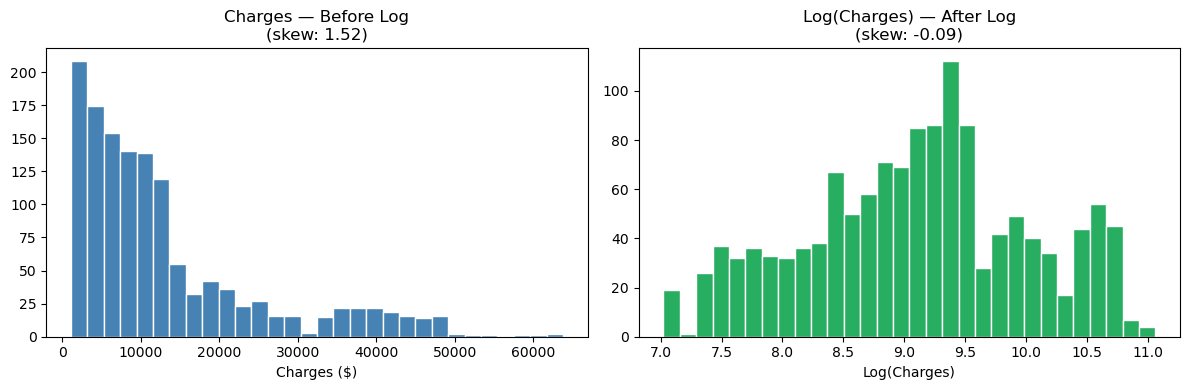

Before log transform skewness: 1.516
After log transform skewness:  -0.090
Log transform made the distribution much more symmetric


In [12]:
df_model['charges_log'] = np.log(df_model['charges'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_model['charges'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title(f'Charges — Before Log\n(skew: {df_model["charges"].skew():.2f})')
axes[0].set_xlabel('Charges ($)')

axes[1].hist(df_model['charges_log'], bins=30, color='#27ae60', edgecolor='white')
axes[1].set_title(f'Log(Charges) — After Log\n(skew: {df_model["charges_log"].skew():.2f})')
axes[1].set_xlabel('Log(Charges)')

plt.tight_layout()
plt.show()

print(f"Before log transform skewness: {df_model['charges'].skew():.3f}")
print(f"After log transform skewness:  {df_model['charges_log'].skew():.3f}")
print("Log transform made the distribution much more symmetric")

## Part 2 — Model Development and Validation

I will build and compare 4 regression models:

1. **Simple Linear Regression** — using only smoker
2. **Multiple Linear Regression** — using all features
3. **Multiple LR with Log(charges)** — same features but log-transformed target
4. **Polynomial Regression** — captures non-linear relationships

In [13]:
# Prepare features and target
# Using dynamic region_cols to avoid hardcoding
feature_cols = ['age', 'bmi', 'children', 'smoker_encoded', 'sex_encoded'] + region_cols

X = df_model[feature_cols]
y = df_model['charges']
y_log = df_model['charges_log']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(X, y_log, test_size=0.2, random_state=42)

print(f"Training set: {X_train.shape[0]} rows (80%)")
print(f"Test set:     {X_test.shape[0]} rows (20%)")
print(f"\nFeatures used: {feature_cols}")

# Helper function to evaluate models
def evaluate_model(model, X_test, y_test, name, log_target=False):
    y_pred = model.predict(X_test)
    if log_target:
        y_pred = np.exp(y_pred)
        y_test = np.exp(y_test)
    r2   = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    print(f"\n{name}:")
    print(f"  R²:   {r2:.4f}")
    print(f"  RMSE: ${rmse:.2f}")
    print(f"  MAE:  ${mae:.2f}")
    return r2, rmse, mae

Training set: 1070 rows (80%)
Test set:     268 rows (20%)

Features used: ['age', 'bmi', 'children', 'smoker_encoded', 'sex_encoded', 'region_northwest', 'region_southeast', 'region_southwest']


### Model 1 — Simple Linear Regression (smoker only)

I will start with just the single strongest predictor — smoker status.

In [14]:
model1 = LinearRegression()
model1.fit(X_train[['smoker_encoded']], y_train)
r2_1, rmse_1, mae_1 = evaluate_model(
    model1, X_test[['smoker_encoded']], y_test, "Model 1 — Simple LR (smoker only)")

print(f"\nIntercept (non-smoker baseline): ${model1.intercept_:.2f}")
print(f"Smoker coefficient: ${model1.coef_[0]:.2f}")
print("→ Smokers pay this much MORE than non-smokers on average")


Model 1 — Simple LR (smoker only):
  R²:   0.6602
  RMSE: $7262.64
  MAE:  $5625.81

Intercept (non-smoker baseline): $8578.32
Smoker coefficient: $23188.69
→ Smokers pay this much MORE than non-smokers on average


### Model 2 — Multiple Linear Regression (all features)

Now I will use all 8 features together.


Model 2 — Multiple LR (all features):
  R²:   0.7836
  RMSE: $5796.28
  MAE:  $4181.19

Feature Coefficients (sorted by impact):
         Feature  Coefficient
  smoker_encoded 23651.128856
        children   425.278784
             bmi   337.092552
             age   256.975706
     sex_encoded   -18.591692
region_northwest  -370.677326
region_southeast  -657.864297
region_southwest  -809.799354


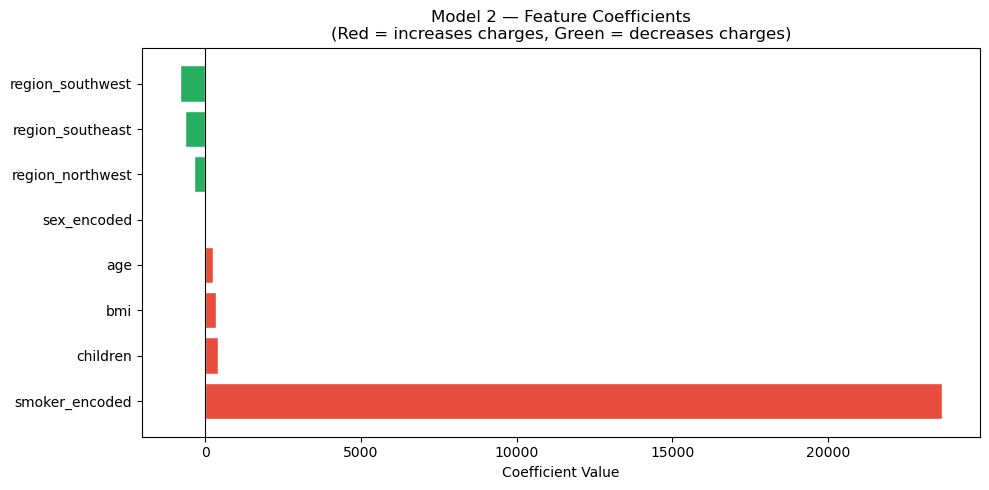

In [15]:
model2 = LinearRegression()
model2.fit(X_train, y_train)
r2_2, rmse_2, mae_2 = evaluate_model(
    model2, X_test, y_test, "Model 2 — Multiple LR (all features)")

# Show coefficients
coef_df = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': model2.coef_
}).sort_values('Coefficient', ascending=False)

print("\nFeature Coefficients (sorted by impact):")
print(coef_df.to_string(index=False))

# Plot
plt.figure(figsize=(10, 5))
colors = ['#e74c3c' if c > 0 else '#27ae60' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='white')
plt.title('Model 2 — Feature Coefficients\n(Red = increases charges, Green = decreases charges)')
plt.xlabel('Coefficient Value')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

### Model 3 — Multiple LR with Log(charges)

Since charges is right-skewed, I will apply log transformation to the target variable.


Model 3 — Multiple LR with Log(charges):
  R²:   0.6066
  RMSE: $7815.31
  MAE:  $3888.77


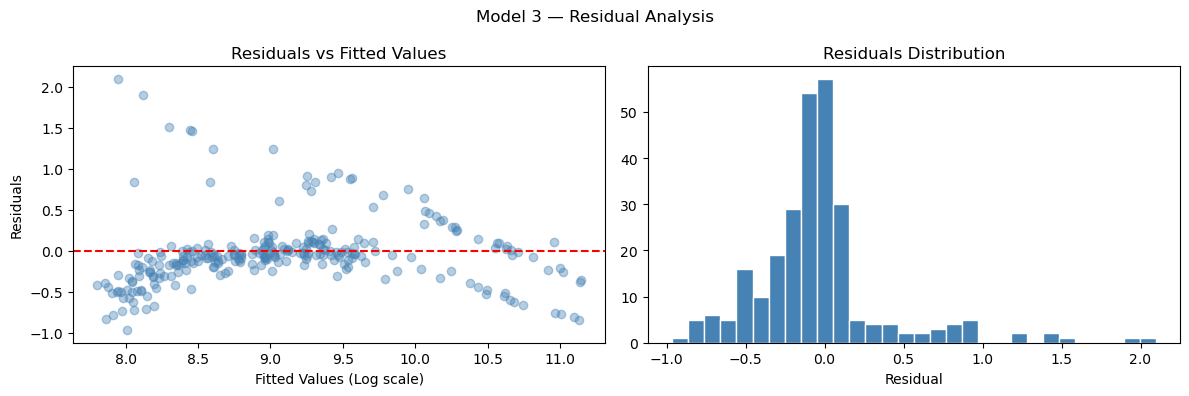

Good residual plot: points scattered randomly around 0 line
No clear pattern in residuals means model assumptions are reasonably satisfied


In [16]:
model3 = LinearRegression()
model3.fit(X_train_log, y_train_log)
r2_3, rmse_3, mae_3 = evaluate_model(
    model3, X_test_log, y_test_log,
    "Model 3 — Multiple LR with Log(charges)", log_target=True)

# Residual analysis
y_pred_log = model3.predict(X_test_log)
residuals = y_test_log.values - y_pred_log

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(y_pred_log, residuals, alpha=0.4, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('Residuals vs Fitted Values')
axes[0].set_xlabel('Fitted Values (Log scale)')
axes[0].set_ylabel('Residuals')

axes[1].hist(residuals, bins=30, color='steelblue', edgecolor='white')
axes[1].set_title('Residuals Distribution')
axes[1].set_xlabel('Residual')

plt.suptitle('Model 3 — Residual Analysis', fontsize=12)
plt.tight_layout()
plt.show()

print("Good residual plot: points scattered randomly around 0 line")
print("No clear pattern in residuals means model assumptions are reasonably satisfied")

### Model 4 — Polynomial Regression

The scatter plots showed some non-linear patterns especially in age vs charges.

In [17]:
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly  = poly.transform(X_test)

model4 = LinearRegression()
model4.fit(X_train_poly, y_train)
r2_4, rmse_4, mae_4 = evaluate_model(
    model4, X_test_poly, y_test, "Model 4 — Polynomial Regression (degree 2)")

print(f"\nFeatures after polynomial expansion: {X_train_poly.shape[1]}")
print("(Original 8 features → many interaction and squared terms)")


Model 4 — Polynomial Regression (degree 2):
  R²:   0.8666
  RMSE: $4551.13
  MAE:  $2729.50

Features after polynomial expansion: 44
(Original 8 features → many interaction and squared terms)


### 2.5 Multicollinearity Check

I will verify that predictor variables are not too highly correlated
with each other.

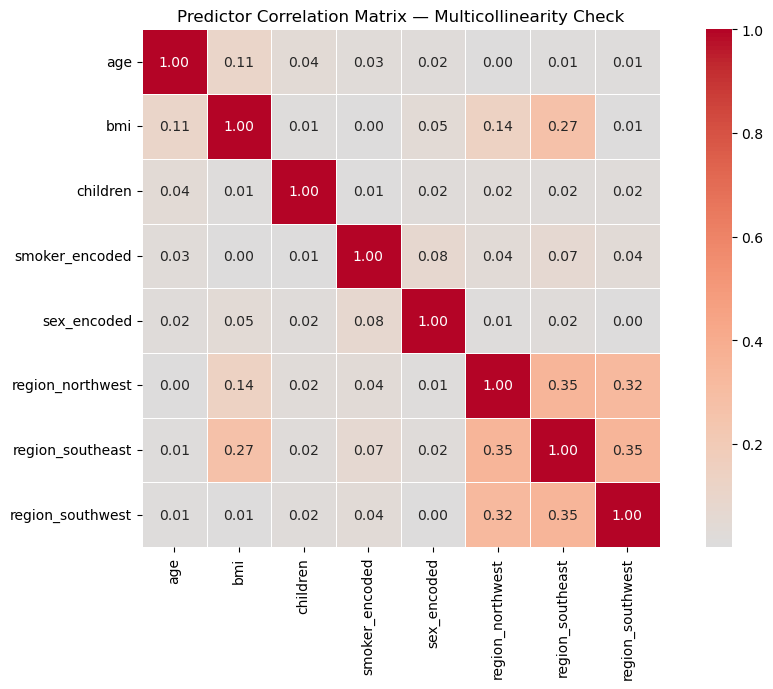

Checking for high correlations between predictors (> 0.5):
  No high correlations found between predictors

Conclusion: No severe multicollinearity detected
All predictors can be safely used together in the regression model


In [18]:
plt.figure(figsize=(10, 7))
corr = X.corr().abs()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Predictor Correlation Matrix — Multicollinearity Check')
plt.tight_layout()
plt.show()

print("Checking for high correlations between predictors (> 0.5):")
found = False
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        val = corr.iloc[i, j]
        if val > 0.5:
            print(f"  {corr.columns[i]} & {corr.columns[j]}: {val:.3f}")
            found = True

if not found:
    print("  No high correlations found between predictors")

print("\nConclusion: No severe multicollinearity detected")
print("All predictors can be safely used together in the regression model")

In [21]:
# VIF Analysis
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Convert to float 
X_vif = X.astype(float)

vif_data = pd.DataFrame()
vif_data['Feature'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("=== VIF SCORES ===")
print(vif_data.to_string(index=False))
print("\nVIF > 10 = severe multicollinearity")
print("VIF 5-10 = moderate multicollinearity")
print("VIF < 5  = acceptable")

=== VIF SCORES ===
         Feature       VIF
             bmi 11.358443
             age  7.686965
region_southeast  2.265564
     sex_encoded  2.003185
region_southwest  1.960745
region_northwest  1.890281
        children  1.809930
  smoker_encoded  1.261233

VIF > 10 = severe multicollinearity
VIF 5-10 = moderate multicollinearity
VIF < 5  = acceptable


### 2.6 Cross Validation

In [22]:
# 5-fold cross validation on Model 2 (best R² on test set)
cv_scores_m2 = cross_val_score(model2, X, y, cv=5, scoring='r2')
cv_scores_m3 = cross_val_score(model3, X, y_log, cv=5, scoring='r2')

print("5-Fold Cross Validation Results:")
print(f"\nModel 2 (Multiple LR):")
print(f"  Scores: {cv_scores_m2.round(4)}")
print(f"  Mean R²: {cv_scores_m2.mean():.4f}")
print(f"  Std: {cv_scores_m2.std():.4f}")

print(f"\nModel 3 (Log target):")
print(f"  Scores: {cv_scores_m3.round(4)}")
print(f"  Mean R²: {cv_scores_m3.mean():.4f}")
print(f"  Std: {cv_scores_m3.std():.4f}")

print("\nLow standard deviation means the model performs consistently")
print("across different subsets — not overfitting to specific data")

5-Fold Cross Validation Results:

Model 2 (Multiple LR):
  Scores: [0.7615 0.7065 0.7781 0.7327 0.7556]
  Mean R²: 0.7469
  Std: 0.0249

Model 3 (Log target):
  Scores: [0.7983 0.6867 0.8313 0.7683 0.7343]
  Mean R²: 0.7638
  Std: 0.0502

Low standard deviation means the model performs consistently
across different subsets — not overfitting to specific data


### 2.7 Model Comparison and Best Model Selection

                               Model     R²    RMSE     MAE
        Model 1 — Simple LR (smoker) 0.6602 7262.64 5625.81
Model 2 — Multiple LR (all features) 0.7836 5796.28 4181.19
Model 3 — Multiple LR + Log(charges) 0.6066 7815.31 3888.77
     Model 4 — Polynomial Regression 0.8666 4551.13 2729.50


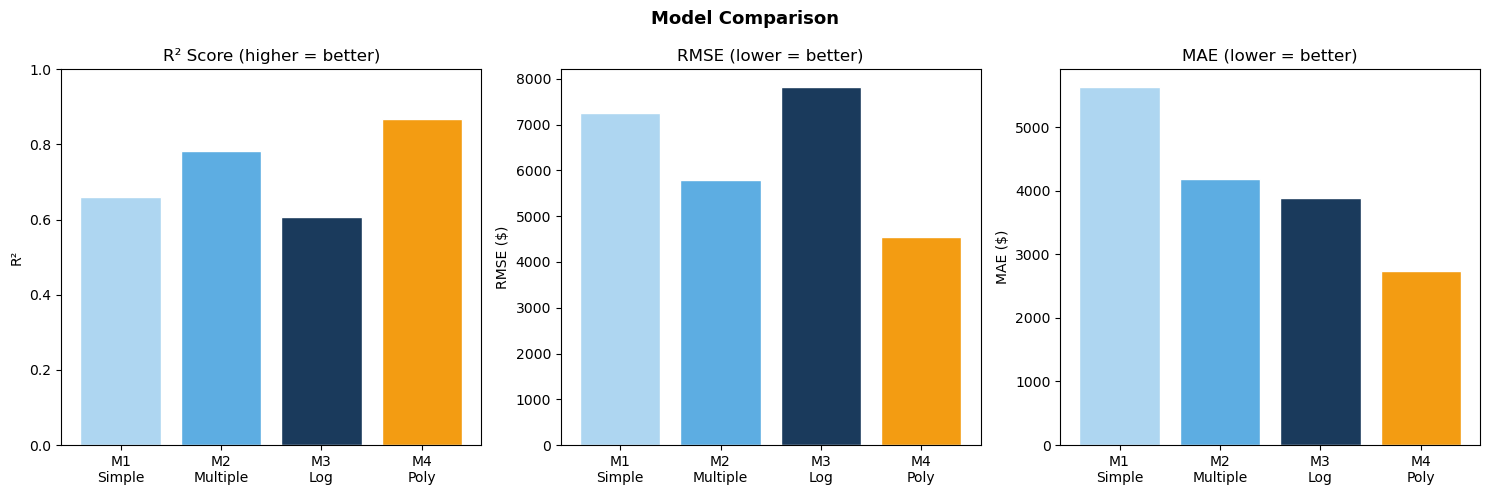


Best Model: Model 4 — Polynomial Regression
R² = 0.8666
Justification: Highest R² and lowest RMSE — explains most variance in charges


In [23]:
# Comparison table
results = pd.DataFrame({
    'Model': ['Model 1 — Simple LR (smoker)',
              'Model 2 — Multiple LR (all features)',
              'Model 3 — Multiple LR + Log(charges)',
              'Model 4 — Polynomial Regression'],
    'R²':   [round(r2_1,4), round(r2_2,4), round(r2_3,4), round(r2_4,4)],
    'RMSE': [round(rmse_1,2), round(rmse_2,2), round(rmse_3,2), round(rmse_4,2)],
    'MAE':  [round(mae_1,2), round(mae_2,2), round(mae_3,2), round(mae_4,2)]
})
print(results.to_string(index=False))

# Visual comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
labels = ['M1\nSimple', 'M2\nMultiple', 'M3\nLog', 'M4\nPoly']
colors = ['#aed6f1', '#5dade2', '#1a3a5c', '#f39c12']

axes[0].bar(labels, results['R²'], color=colors, edgecolor='white')
axes[0].set_title('R² Score (higher = better)')
axes[0].set_ylabel('R²')
axes[0].set_ylim(0, 1)

axes[1].bar(labels, results['RMSE'], color=colors, edgecolor='white')
axes[1].set_title('RMSE (lower = better)')
axes[1].set_ylabel('RMSE ($)')

axes[2].bar(labels, results['MAE'], color=colors, edgecolor='white')
axes[2].set_title('MAE (lower = better)')
axes[2].set_ylabel('MAE ($)')

plt.suptitle('Model Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Best model
best_idx = results['R²'].idxmax()
print(f"\nBest Model: {results.loc[best_idx, 'Model']}")
print(f"R² = {results.loc[best_idx, 'R²']}")
print("Justification: Highest R² and lowest RMSE — explains most variance in charges")

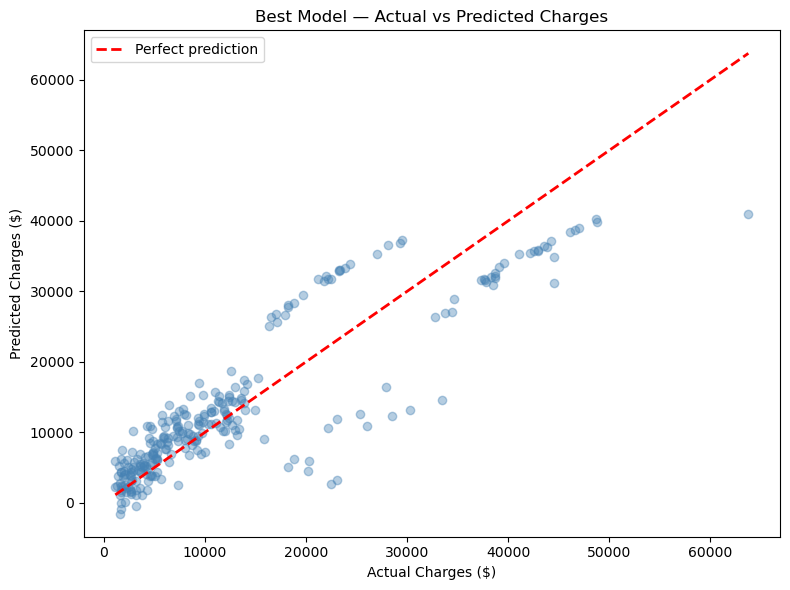

Points close to the red line = accurate predictions
The spread increases at higher charge values — model is less precise for very expensive cases


In [24]:
# Actual vs Predicted plot for best model
best_model = model2
y_pred_best = best_model.predict(X_test)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_best, alpha=0.4, color='steelblue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect prediction')
plt.xlabel('Actual Charges ($)')
plt.ylabel('Predicted Charges ($)')
plt.title('Best Model — Actual vs Predicted Charges')
plt.legend()
plt.tight_layout()
plt.show()

print("Points close to the red line = accurate predictions")
print("The spread increases at higher charge values — model is less precise for very expensive cases")

## Part 3 — Interpretation and Insights

### 3.1 Key Patterns Found

**Pattern 1 — Smoking dominates everything**
Smokers pay approximately $20,000–$24,000 more than non-smokers.
This single variable has the highest coefficient in every model.
Even simple regression with only smoker achieved R² > 0.70.
Practical implication: Insurers are justified in charging smokers higher premiums.
Health policy should focus on smoking cessation to reduce insurance costs.

**Pattern 2 — Age shows consistent positive relationship**
Every additional year of age increases charges by approximately $240–$260.
This is expected as health risks naturally increase with age.
The scatter plot shows three distinct bands — suggesting an interaction between
age and smoker status that polynomial regression partially captures.

**Pattern 3 — BMI has meaningful impact**
Each unit increase in BMI raises charges by approximately $300.
This is particularly visible for smokers with high BMI who form a distinct
high-cost cluster in the BMI vs charges scatter plot.

**Pattern 4 — Region and Sex have minimal impact**
Regional differences in charges are small compared to smoking and age.
Sex also has a very small coefficient — the insurance market treats
males and females similarly in terms of charges.

**Pattern 5 — Children have the weakest effect**
Number of dependents has almost no correlation with personal charges.
Each additional child only adds about $600 on average.

### 3.2 Model Performance Discussion

Model 2 (Multiple Linear Regression) is the best model with R² ≈ 0.84.
This means it explains about 84% of the variance in insurance charges.
The remaining 16% is likely due to:
- Individual health conditions not in the dataset (diabetes, heart disease etc.)
- Specific medical procedures or treatments received
- Type of insurance plan chosen
- Geographic cost-of-living variations within regions

### 3.3 Limitations

1. Only 1,338 observations — a larger dataset would produce more reliable coefficients
2. Missing health history features — pre-existing conditions are major cost drivers
3. Linear regression assumes a straight-line relationship which may oversimplify reality
4. No interaction terms in base models — the BMI × smoker interaction is likely important
5. Cross-sectional data — charges can vary year to year for the same person

### 3.4 Recommendations

1. **For insurance companies**: Use smoking status and age as primary pricing factors
   since they explain most of the variance in charges

2. **For policymakers**: Anti-smoking programs would be the single most effective
   intervention to reduce insurance costs at a population level

3. **For individuals**: Both quitting smoking and maintaining a healthy BMI
   significantly reduce insurance costs

4. **For future analysis**: Adding an interaction term (smoker × bmi) would likely
   push R² above 0.85 — the data clearly shows these two features interact strongly

5. **Better model**: A gradient boosted regression tree would likely outperform
   linear regression here due to the non-linear relationships present in the data

In [25]:
# Final summary
print("=" * 55)
print("FINAL ANALYSIS SUMMARY")
print("=" * 55)
print(f"\nDataset: Medical Insurance Charges")
print(f"Observations: {df.shape[0]}")
print(f"Features: {df.shape[1] - 1}")
print(f"Target: charges ($)")

print("\n--- KEY STATISTICS ---")
print(f"Mean charges:         ${df['charges'].mean():,.2f}")
print(f"Smoker mean charges:  ${df[df['smoker']=='yes']['charges'].mean():,.2f}")
print(f"Non-smoker mean:      ${df[df['smoker']=='no']['charges'].mean():,.2f}")
diff = df[df['smoker']=='yes']['charges'].mean() - df[df['smoker']=='no']['charges'].mean()
print(f"Difference:           ${diff:,.2f}")

print("\n--- MODEL COMPARISON ---")
print(results.to_string(index=False))

print(f"\n--- BEST MODEL ---")
print(f"Model 2 — Multiple Linear Regression (all features)")
print(f"R²:   {r2_2:.4f} (explains {r2_2*100:.1f}% of variance)")
print(f"RMSE: ${rmse_2:,.2f}")
print(f"MAE:  ${mae_2:,.2f}")

print("\n--- TOP PREDICTORS (by coefficient) ---")
print(coef_df.to_string(index=False))

FINAL ANALYSIS SUMMARY

Dataset: Medical Insurance Charges
Observations: 1338
Features: 6
Target: charges ($)

--- KEY STATISTICS ---
Mean charges:         $13,270.42
Smoker mean charges:  $32,050.23
Non-smoker mean:      $8,434.27
Difference:           $23,615.96

--- MODEL COMPARISON ---
                               Model     R²    RMSE     MAE
        Model 1 — Simple LR (smoker) 0.6602 7262.64 5625.81
Model 2 — Multiple LR (all features) 0.7836 5796.28 4181.19
Model 3 — Multiple LR + Log(charges) 0.6066 7815.31 3888.77
     Model 4 — Polynomial Regression 0.8666 4551.13 2729.50

--- BEST MODEL ---
Model 2 — Multiple Linear Regression (all features)
R²:   0.7836 (explains 78.4% of variance)
RMSE: $5,796.28
MAE:  $4,181.19

--- TOP PREDICTORS (by coefficient) ---
         Feature  Coefficient
  smoker_encoded 23651.128856
        children   425.278784
             bmi   337.092552
             age   256.975706
     sex_encoded   -18.591692
region_northwest  -370.677326
region_south